In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("spam.csv", encoding="latin1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [5]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df = df.rename(columns={"v1": "label", "v2": "message"})
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
df = df.dropna()

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(5169, 2)

In [12]:
df["label"].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

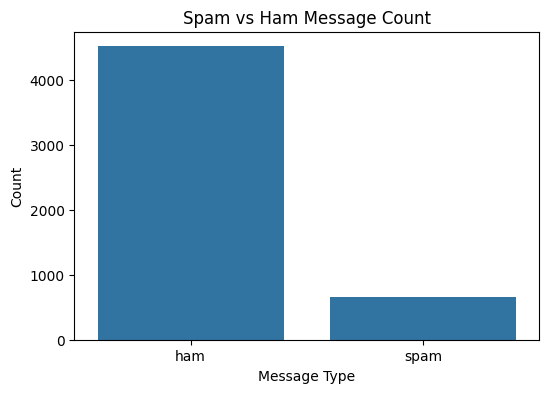

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Spam vs Ham Message Count")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [14]:
df["message_length"] = df["message"].apply(len)
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


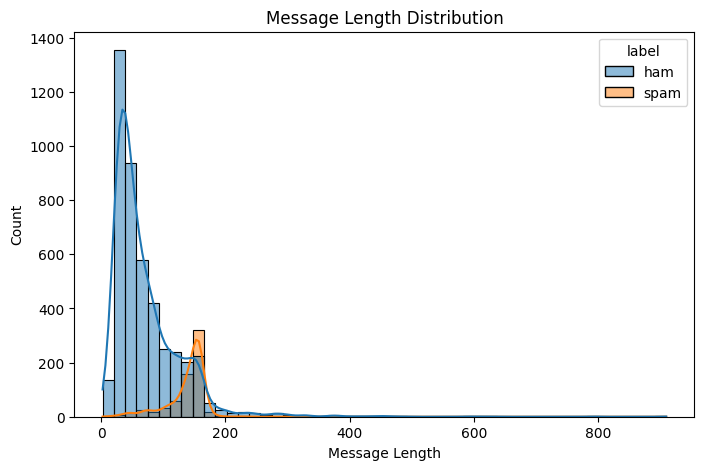

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="message_length", hue="label", bins=50, kde=True)
plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Count")
plt.show()

In [16]:
df["label_num"] = df["label"].map({"ham": 0, "spam": 1})
df.head()

,label,message,message_length,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


In [17]:
X = df["message"]
y = df["label_num"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(4135,)
(1034,)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [21]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [22]:
predictions = model.predict(X_test_tfidf)

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", cm)

print("Classification Report:\n", classification_report(y_test, predictions))

Accuracy: 0.9661508704061895
Confusion Matrix:
 [[889   0]
 [ 35 110]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.76      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



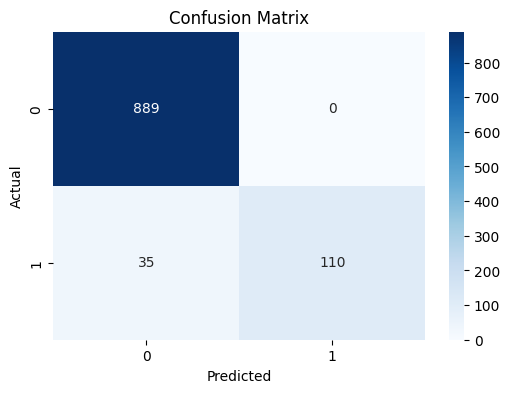

In [24]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
sample1 = ["Congratulations! You have won a free lottery ticket. Claim now!"]
sample1_tfidf = vectorizer.transform(sample1)
print("Prediction:", model.predict(sample1_tfidf))

Prediction: [1]


In [26]:
sample2 = ["Hey Soham, are you coming to college tomorrow?"]
sample2_tfidf = vectorizer.transform(sample2)
print("Prediction:", model.predict(sample2_tfidf))

Prediction: [0]


In [27]:
sample = ["Congratulations! You have won a free lottery ticket. Claim now!"]
sample_tfidf = vectorizer.transform(sample)
pred = model.predict(sample_tfidf)[0]

if pred == 1:
    print("The message is Spam")
else:
    print("The message is Ham")

The message is Spam


In [30]:
message = ["Hey Soham, are you coming to college tomorrow?"]

message_tfidf = vectorizer.transform(message)
prediction = model.predict(message_tfidf)[0]

if prediction == 1:
    print("This message is Spam")
else:
    print("This message is Ham")

This message is Ham


In [31]:
messages = [
    "Win a free iPhone now!",
    "Let's meet tomorrow for lunch",
    "Claim your reward by clicking this link",
    "Are you coming to the meeting?"
]

messages_tfidf = vectorizer.transform(messages)
predictions = model.predict(messages_tfidf)

for msg, pred in zip(messages, predictions):
    if pred == 1:
        print(msg, "-> Spam")
    else:
        print(msg, "-> Ham")

Win a free iPhone now! -> Ham
Let's meet tomorrow for lunch -> Ham
Claim your reward by clicking this link -> Spam
Are you coming to the meeting? -> Ham
